Unique particle IDs found: [0.  0.1 0.2 0.3 0.4 0.5 0.6]
Signal events: 45208
Background events: 109817

Particle counts by ID (signal):
  ID = 0.00:   439478 particles (36.7%)
  ID = 0.10:   340221 particles (28.4%)
  ID = 0.20:   319050 particles (26.7%)
  ID = 0.30:    96437 particles (8.1%)
  ID = 0.40:      612 particles (0.1%)
  ID = 0.50:      589 particles (0.0%)
  ID = 0.60:       25 particles (0.0%)

Particle counts by ID (background):
  ID = 0.00:   761683 particles (23.0%)
  ID = 0.10:  1005333 particles (30.3%)
  ID = 0.20:   931855 particles (28.1%)
  ID = 0.30:   613954 particles (18.5%)
  ID = 0.40:      406 particles (0.0%)
  ID = 0.50:      405 particles (0.0%)
  ID = 0.60:      566 particles (0.0%)

Channel mapping:
  Channel 0: Type A (flag=0.0)
  Channel 1: Type B (flag=0.1)
  Channel 2: Type C (flag=0.2)
  Channel 3: ID=0.30
  Channel 4: ID=0.40
  Channel 5: ID=0.50
  Channel 6: ID=0.60

Generating multi-channel jet images...
  Signal multi-channel images: (45208,

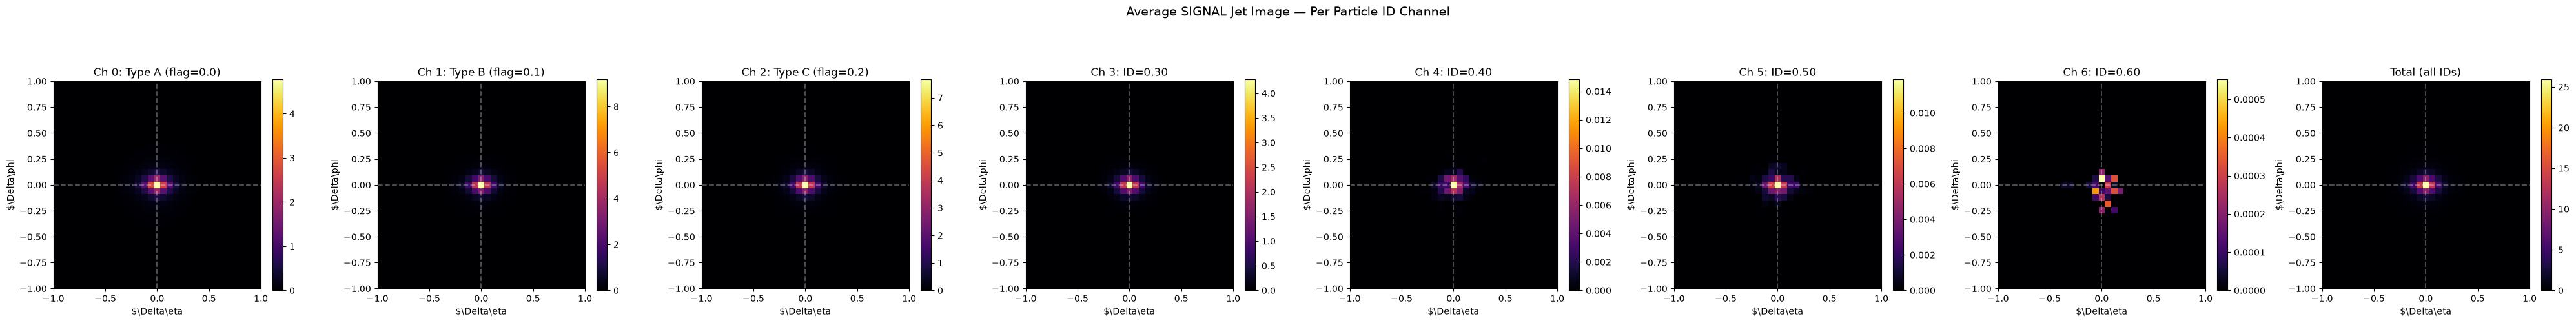

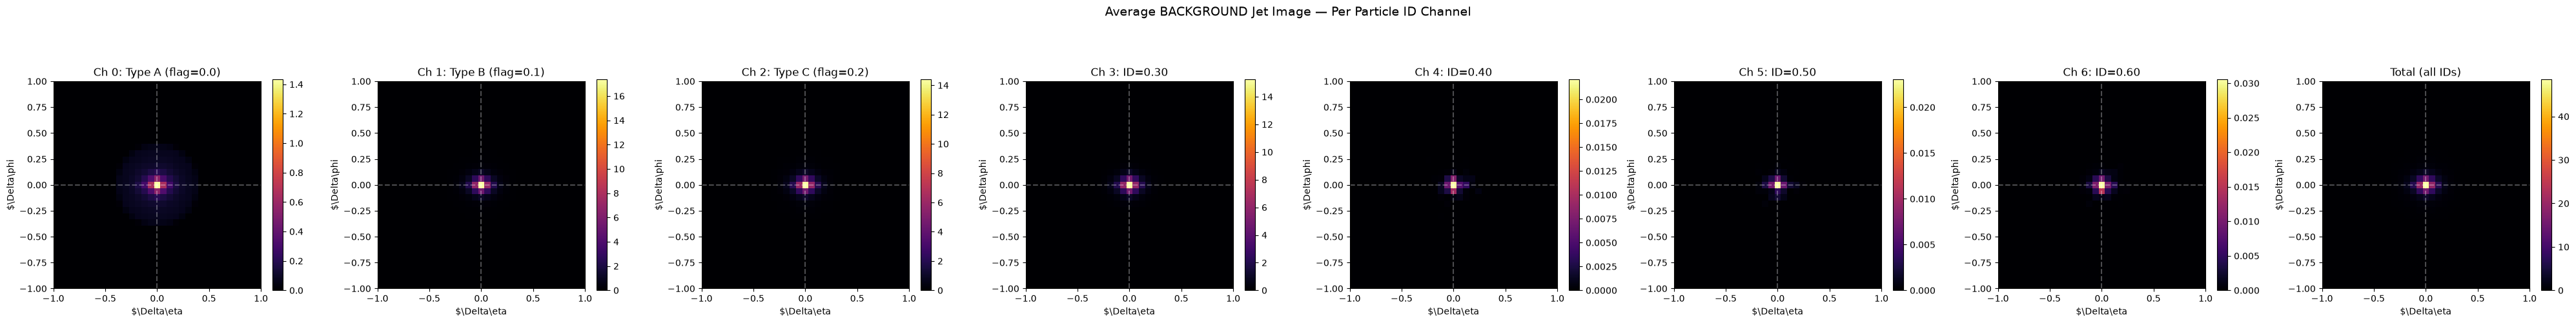

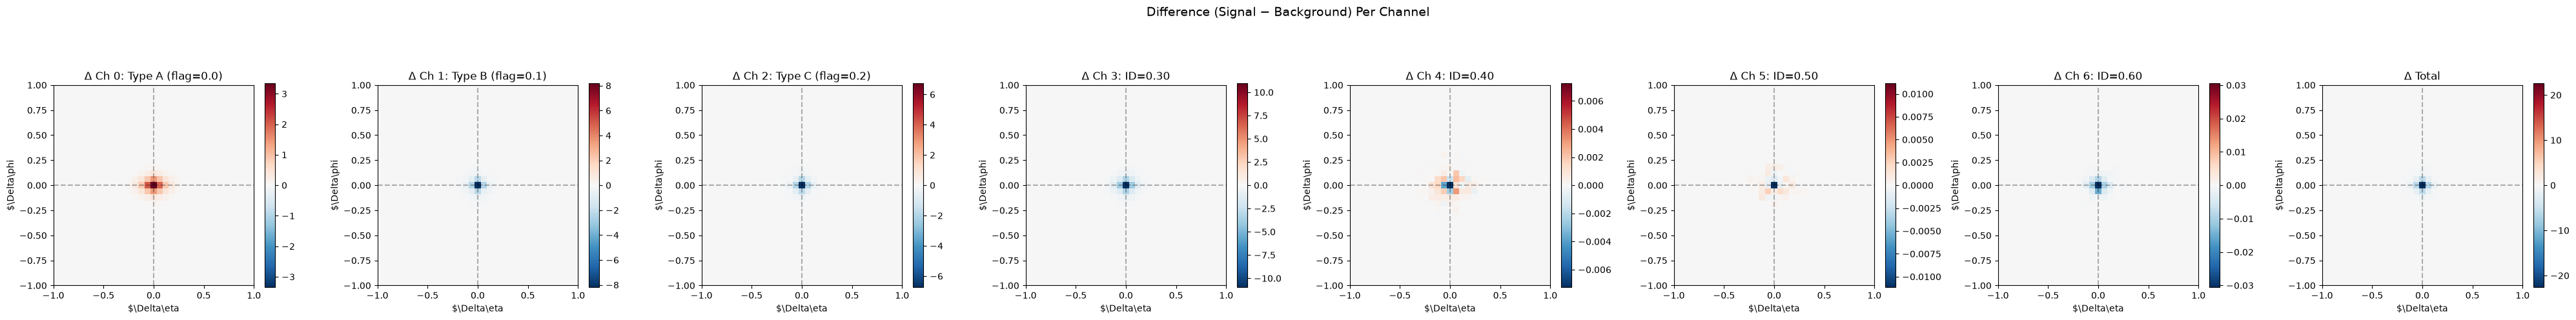

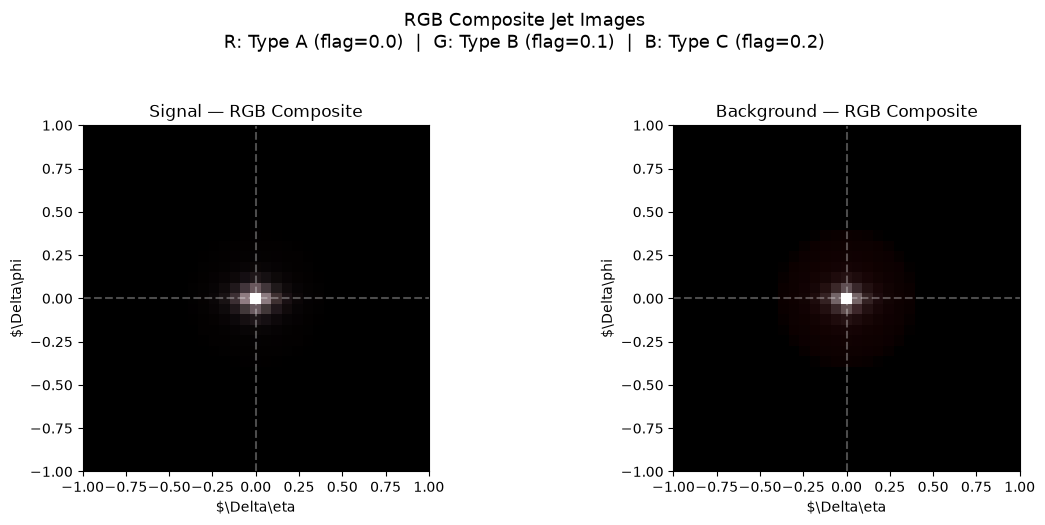

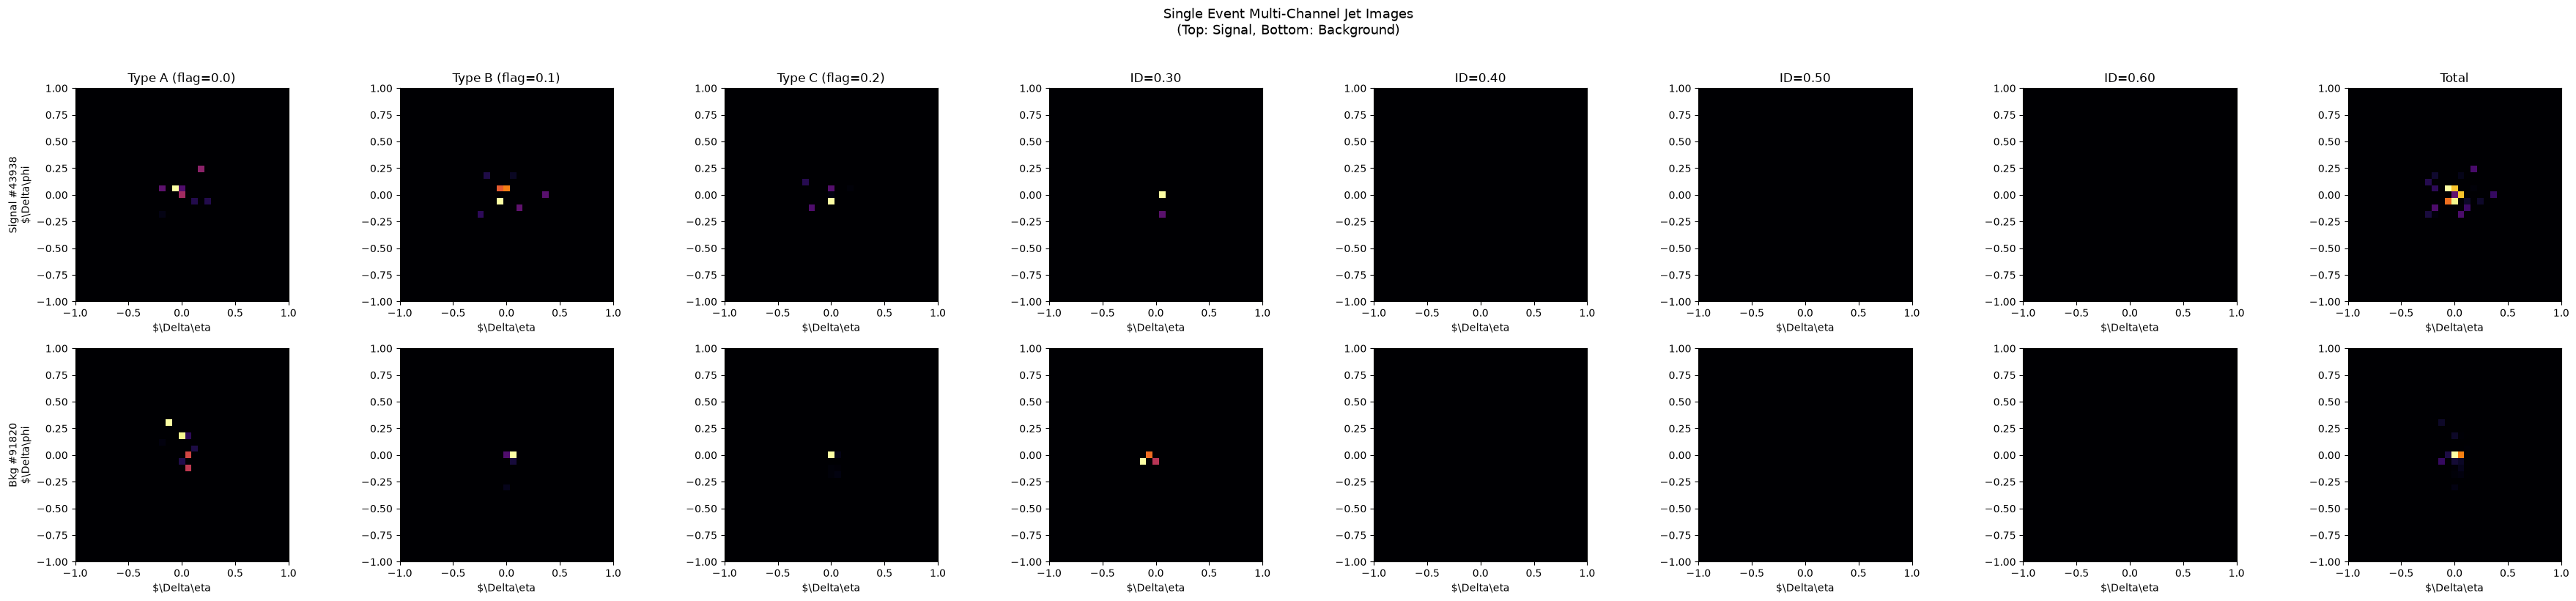

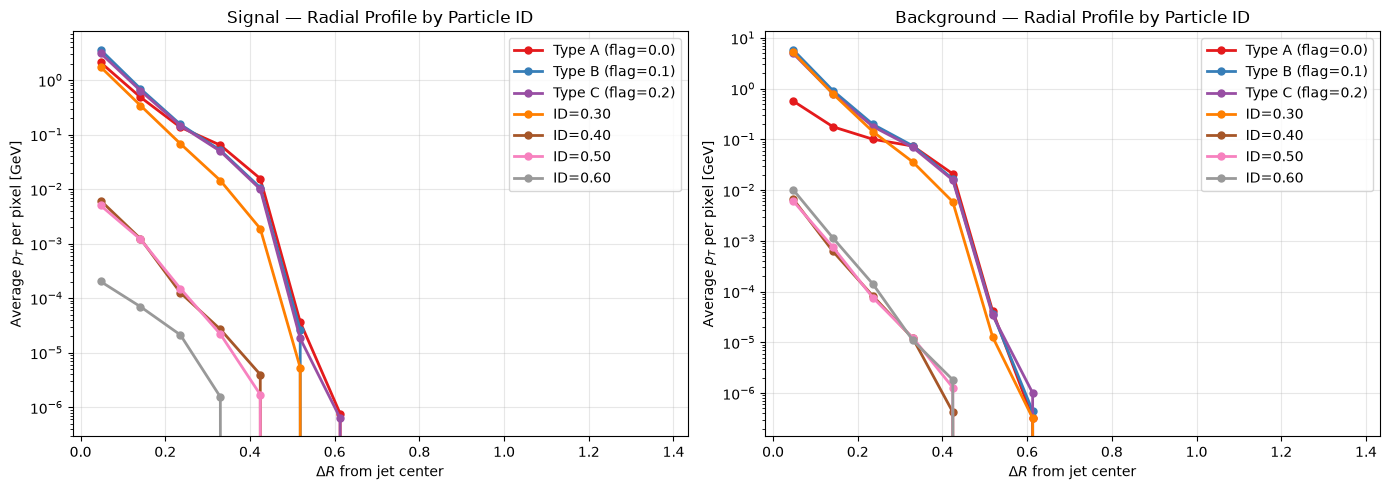

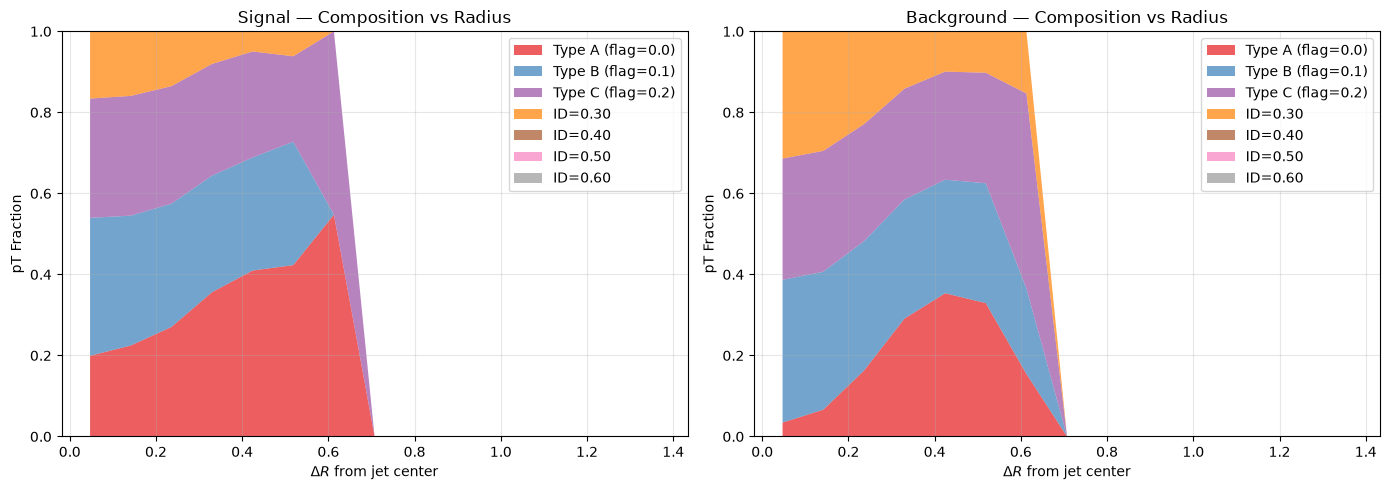

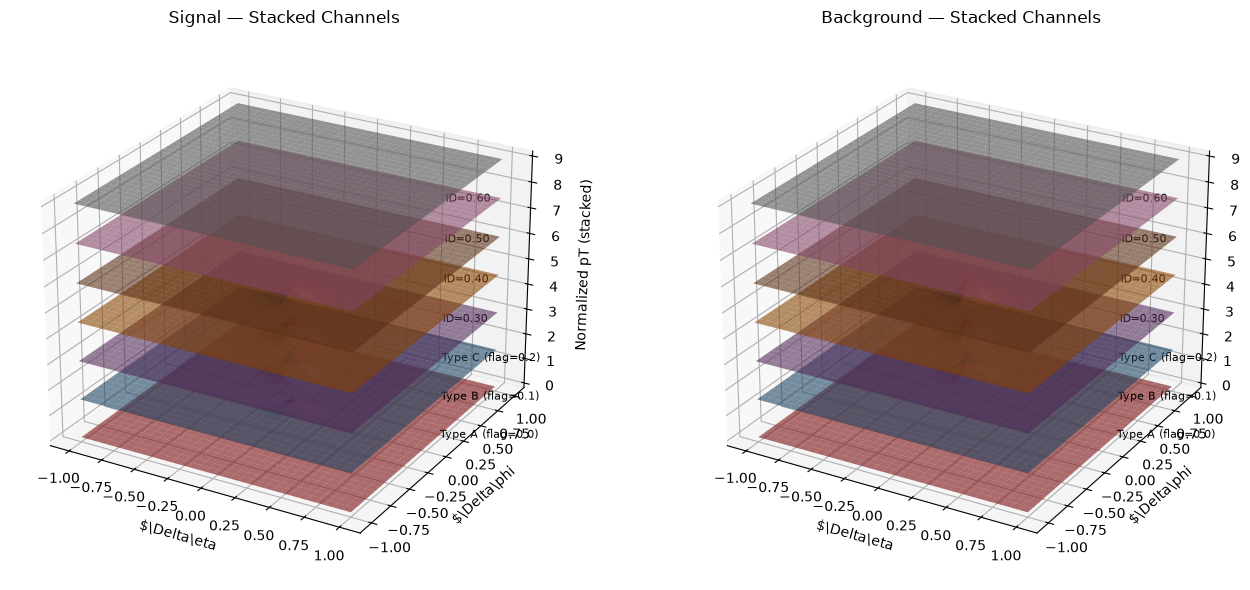


MULTI-CHANNEL JET IMAGE STATISTICS

Image shape per event: (7, 33, 33)
Total pixels per event: 7623
Image range: Δη ∈ [-1.0, 1.0], Δφ ∈ [-1.0, 1.0]
Pixel size: Δη = 0.0606, Δφ = 0.0606

Channel                    Sig avg pT/img  Bkg avg pT/img   Sig/Bkg ratio
----------------------------------------------------------------------
Type A (flag=0.0)                   37.98           17.33           2.191
Type B (flag=0.1)                   55.41           83.23           0.666
Type C (flag=0.2)                   49.53           72.02           0.688
ID=0.30                             26.03           70.18           0.371
ID=0.40                              0.09            0.08           1.132
ID=0.50                              0.08            0.07           1.032
ID=0.60                              0.00            0.12           0.034
TOTAL                              169.12          243.05           0.696

Channel                     Sig occupancy   Bkg occupancy
-----------------

In [2]:
# ============================================================
# MULTI-CHANNEL JET IMAGES — One Layer Per Particle ID
# ============================================================
# Instead of summing all particles into one image, we create
# separate layers based on the particle flag/ID value.
#
# This is analogous to RGB channels in computer vision:
#   - Channel 0: particles with flag = 0.0
#   - Channel 1: particles with flag = 0.1
#   - Channel 2: particles with flag = 0.2
#   (extend for more ID values as needed)
#
# This gives the CNN richer information about jet substructure —
# different particle types deposit energy in different patterns.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ============================================================
# 1. LOAD AND PARSE DATA (same as before)
# ============================================================

sig_df = pd.read_csv('data/CoLBTHydro.csv', header=None)
bkg_df = pd.read_csv('data/Jewel.csv', header=None)

MAX_PARTICLES = 50
N_FEAT_PER_PARTICLE = 4        # pT, eta, phi, flag
OBJ_START = 8


def parse_particles_with_id(df, max_particles=MAX_PARTICLES):
    """
    Parse raw CSV into per-particle arrays including particle ID.
    
    Returns:
    --------
    pt : (n_events, max_particles)
    eta : (n_events, max_particles)
    phi : (n_events, max_particles)
    pid : (n_events, max_particles) — particle ID/flag
    mask : (n_events, max_particles)
    """
    raw = df.values
    n_events = len(df)
    
    pt = np.zeros((n_events, max_particles))
    eta = np.zeros((n_events, max_particles))
    phi = np.zeros((n_events, max_particles))
    pid = np.full((n_events, max_particles), -1.0)         # -1 = no particle
    mask = np.zeros((n_events, max_particles))
    
    for i in range(n_events):
        n_obj = int(raw[i, 0])
        n_obj = min(n_obj, max_particles)
        for j in range(n_obj):
            col_start = OBJ_START + j * N_FEAT_PER_PARTICLE
            col_end = col_start + N_FEAT_PER_PARTICLE
            if col_end <= raw.shape[1]:
                pt[i, j] = raw[i, col_start]
                eta[i, j] = raw[i, col_start + 1]
                phi[i, j] = raw[i, col_start + 2]
                pid[i, j] = raw[i, col_start + 3]         # Particle ID / flag
                mask[i, j] = 1.0
    
    return pt, eta, phi, pid, mask


# Parse signal and background
sig_pt, sig_eta, sig_phi, sig_pid, sig_mask = parse_particles_with_id(sig_df)
bkg_pt, bkg_eta, bkg_phi, bkg_pid, bkg_mask = parse_particles_with_id(bkg_df)

# Discover unique particle IDs in the data
all_pids = np.unique(sig_pid[sig_mask == 1])
print(f"Unique particle IDs found: {all_pids}")
print(f"Signal events: {sig_pt.shape[0]}")
print(f"Background events: {bkg_pt.shape[0]}")

# Count particles per ID
print("\nParticle counts by ID (signal):")
for pid_val in all_pids:
    count = (sig_pid[sig_mask == 1] == pid_val).sum()
    frac = count / sig_mask.sum() * 100
    print(f"  ID = {pid_val:.2f}: {count:>8d} particles ({frac:.1f}%)")

print("\nParticle counts by ID (background):")
for pid_val in all_pids:
    count = (bkg_pid[bkg_mask == 1] == pid_val).sum()
    frac = count / bkg_mask.sum() * 100
    print(f"  ID = {pid_val:.2f}: {count:>8d} particles ({frac:.1f}%)")

# ============================================================
# 2. CENTER JETS (same as before)
# ============================================================

def center_jet(pt, eta, phi, mask):
    """Center each jet so pT-weighted centroid is at (0, 0)."""
    pt_masked = pt * mask
    pt_sum = pt_masked.sum(axis=1, keepdims=True)
    pt_sum = np.clip(pt_sum, 1e-10, None)
    
    # pT-weighted eta centroid
    eta_centroid = (pt_masked * eta).sum(axis=1, keepdims=True) / pt_sum
    
    # pT-weighted phi centroid (circular mean)
    mean_sin = (pt_masked * np.sin(phi)).sum(axis=1, keepdims=True) / pt_sum
    mean_cos = (pt_masked * np.cos(phi)).sum(axis=1, keepdims=True) / pt_sum
    phi_centroid = np.arctan2(mean_sin, mean_cos)
    
    # Shift
    delta_eta = (eta - eta_centroid) * mask
    delta_phi = np.arctan2(
        np.sin(phi - phi_centroid), np.cos(phi - phi_centroid)
    ) * mask
    
    return delta_eta, delta_phi


sig_deta, sig_dphi = center_jet(sig_pt, sig_eta, sig_phi, sig_mask)
bkg_deta, bkg_dphi = center_jet(bkg_pt, bkg_eta, bkg_phi, bkg_mask)

# ============================================================
# 3. CREATE MULTI-CHANNEL JET IMAGES
# ============================================================
# One channel per particle ID

N_PIXELS = 33
ETA_RANGE = (-1.0, 1.0)
PHI_RANGE = (-1.0, 1.0)

# Define channel mapping: particle ID → channel index
PARTICLE_IDS = sorted(all_pids.tolist())                   # e.g., [0.0, 0.1, 0.2]
N_CHANNELS = len(PARTICLE_IDS)
ID_TO_CHANNEL = {pid_val: ch for ch, pid_val in enumerate(PARTICLE_IDS)}

# Create human-readable labels for each ID
# (Adjust these based on your physics — these are guesses)
ID_LABELS = {
    0.0: "Type A (flag=0.0)",
    0.1: "Type B (flag=0.1)",
    0.2: "Type C (flag=0.2)"
}
# Fallback for unknown IDs
for pid_val in PARTICLE_IDS:
    if pid_val not in ID_LABELS:
        ID_LABELS[pid_val] = f"ID={pid_val:.2f}"

print(f"\nChannel mapping:")
for pid_val, ch in ID_TO_CHANNEL.items():
    print(f"  Channel {ch}: {ID_LABELS[pid_val]}")


def make_multichannel_jet_images(pt, delta_eta, delta_phi, pid, mask,
                                  particle_ids=PARTICLE_IDS,
                                  n_pixels=N_PIXELS,
                                  eta_range=ETA_RANGE,
                                  phi_range=PHI_RANGE):
    """
    Create multi-channel jet images: one layer per particle ID.
    
    Parameters:
    -----------
    pt : (n_events, max_particles)
    delta_eta : (n_events, max_particles) — centered
    delta_phi : (n_events, max_particles) — centered
    pid : (n_events, max_particles) — particle ID/flag
    mask : (n_events, max_particles)
    particle_ids : list — unique ID values defining channels
    n_pixels : int — image resolution per side
    eta_range, phi_range : tuple — image boundaries
    
    Returns:
    --------
    images : (n_events, n_channels, n_pixels, n_pixels)
    """
    n_events = pt.shape[0]
    n_channels = len(particle_ids)
    images = np.zeros((n_events, n_channels, n_pixels, n_pixels))
    
    # Bin edges
    eta_bins = np.linspace(eta_range[0], eta_range[1], n_pixels + 1)
    phi_bins = np.linspace(phi_range[0], phi_range[1], n_pixels + 1)
    
    for i in range(n_events):
        real = mask[i] == 1                                # Real particles only
        if real.sum() == 0:
            continue
        
        for ch, pid_val in enumerate(particle_ids):
            # Select particles matching this ID
            id_mask = (pid[i] == pid_val) & real
            
            if id_mask.sum() == 0:
                continue                                   # No particles of this type
            
            evt_pt = pt[i, id_mask]
            evt_eta = delta_eta[i, id_mask]
            evt_phi = delta_phi[i, id_mask]
            
            # 2D histogram weighted by pT
            img, _, _ = np.histogram2d(
                evt_eta, evt_phi,
                bins=[eta_bins, phi_bins],
                weights=evt_pt
            )
            images[i, ch] = img
    
    return images


print("\nGenerating multi-channel jet images...")
sig_mc_images = make_multichannel_jet_images(
    sig_pt, sig_deta, sig_dphi, sig_pid, sig_mask
)
bkg_mc_images = make_multichannel_jet_images(
    bkg_pt, bkg_deta, bkg_dphi, bkg_pid, bkg_mask
)

print(f"  Signal multi-channel images: {sig_mc_images.shape}")      # (N, C, 33, 33)
print(f"  Background multi-channel images: {bkg_mc_images.shape}")

# Also create a "total" channel (sum of all channels)
sig_total_images = sig_mc_images.sum(axis=1)               # (N, 33, 33)
bkg_total_images = bkg_mc_images.sum(axis=1)

# ============================================================
# 4. VISUALIZATION — AVERAGE MULTI-CHANNEL JET IMAGES
# ============================================================

# --- 4a. Signal: all channels side by side + total ---
fig, axes = plt.subplots(1, N_CHANNELS + 1, figsize=(5 * (N_CHANNELS + 1), 5))

# Individual channels
for ch in range(N_CHANNELS):
    avg_ch = sig_mc_images[:, ch].mean(axis=0)             # Average over events
    im = axes[ch].imshow(
        avg_ch.T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[ch].set_xlabel(r'$\Delta\eta')
    axes[ch].set_ylabel(r'$\Delta\phi')
    axes[ch].set_title(f'Ch {ch}: {ID_LABELS[PARTICLE_IDS[ch]]}')
    axes[ch].axhline(0, color='white', linestyle='--', alpha=0.3)
    axes[ch].axvline(0, color='white', linestyle='--', alpha=0.3)
    plt.colorbar(im, ax=axes[ch], fraction=0.046)

# Total (all channels summed)
avg_total = sig_total_images.mean(axis=0)
im = axes[-1].imshow(
    avg_total.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal'
)
axes[-1].set_xlabel(r'$\Delta\eta')
axes[-1].set_ylabel(r'$\Delta\phi')
axes[-1].set_title('Total (all IDs)')
axes[-1].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[-1].axvline(0, color='white', linestyle='--', alpha=0.3)
plt.colorbar(im, ax=axes[-1], fraction=0.046)

plt.suptitle('Average SIGNAL Jet Image — Per Particle ID Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('jet_images_multichannel_signal.pdf', bbox_inches='tight')
plt.show()


# --- 4b. Background: all channels side by side + total ---
fig, axes = plt.subplots(1, N_CHANNELS + 1, figsize=(5 * (N_CHANNELS + 1), 5))

for ch in range(N_CHANNELS):
    avg_ch = bkg_mc_images[:, ch].mean(axis=0)
    im = axes[ch].imshow(
        avg_ch.T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[ch].set_xlabel(r'$\Delta\eta')
    axes[ch].set_ylabel(r'$\Delta\phi')
    axes[ch].set_title(f'Ch {ch}: {ID_LABELS[PARTICLE_IDS[ch]]}')
    axes[ch].axhline(0, color='white', linestyle='--', alpha=0.3)
    axes[ch].axvline(0, color='white', linestyle='--', alpha=0.3)
    plt.colorbar(im, ax=axes[ch], fraction=0.046)

avg_total_bkg = bkg_total_images.mean(axis=0)
im = axes[-1].imshow(
    avg_total_bkg.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal'
)
axes[-1].set_xlabel(r'$\Delta\eta')
axes[-1].set_ylabel(r'$\Delta\phi')
axes[-1].set_title('Total (all IDs)')
axes[-1].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[-1].axvline(0, color='white', linestyle='--', alpha=0.3)
plt.colorbar(im, ax=axes[-1], fraction=0.046)

plt.suptitle('Average BACKGROUND Jet Image — Per Particle ID Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('jet_images_multichannel_background.pdf', bbox_inches='tight')
plt.show()


# --- 4c. Difference (Signal - Background) per channel ---
fig, axes = plt.subplots(1, N_CHANNELS + 1, figsize=(5 * (N_CHANNELS + 1), 5))

for ch in range(N_CHANNELS):
    diff_ch = sig_mc_images[:, ch].mean(axis=0) - bkg_mc_images[:, ch].mean(axis=0)
    max_abs = np.abs(diff_ch).max() if np.abs(diff_ch).max() > 0 else 1
    im = axes[ch].imshow(
        diff_ch.T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='RdBu_r', aspect='equal',
        vmin=-max_abs, vmax=max_abs
    )
    axes[ch].set_xlabel(r'$\Delta\eta')
    axes[ch].set_ylabel(r'$\Delta\phi')
    axes[ch].set_title(f'Δ Ch {ch}: {ID_LABELS[PARTICLE_IDS[ch]]}')
    axes[ch].axhline(0, color='black', linestyle='--', alpha=0.3)
    axes[ch].axvline(0, color='black', linestyle='--', alpha=0.3)
    plt.colorbar(im, ax=axes[ch], fraction=0.046)

# Total difference
diff_total = sig_total_images.mean(axis=0) - bkg_total_images.mean(axis=0)
max_abs_t = np.abs(diff_total).max() if np.abs(diff_total).max() > 0 else 1
im = axes[-1].imshow(
    diff_total.T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='RdBu_r', aspect='equal',
    vmin=-max_abs_t, vmax=max_abs_t
)
axes[-1].set_xlabel(r'$\Delta\eta')
axes[-1].set_ylabel(r'$\Delta\phi')
axes[-1].set_title('Δ Total')
axes[-1].axhline(0, color='black', linestyle='--', alpha=0.3)
axes[-1].axvline(0, color='black', linestyle='--', alpha=0.3)
plt.colorbar(im, ax=axes[-1], fraction=0.046)

plt.suptitle('Difference (Signal − Background) Per Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('jet_images_multichannel_difference.pdf', bbox_inches='tight')
plt.show()


# --- 4d. RGB Composite Jet Image ---
# Map the first 3 channels to R, G, B for a composite visualization

if N_CHANNELS >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    def make_rgb_image(mc_images):
        """
        Create an RGB composite from first 3 channels.
        Each channel is independently normalized to [0, 1].
        """
        avg_img = mc_images.mean(axis=0)                   # (C, H, W)
        rgb = np.zeros((N_PIXELS, N_PIXELS, 3))
        for c in range(min(3, N_CHANNELS)):
            ch_data = avg_img[c].T                         # Transpose for display
            ch_max = ch_data.max()
            if ch_max > 0:
                rgb[:, :, c] = ch_data / ch_max            # Normalize to [0, 1]
        return rgb
    
    # Signal RGB
    sig_rgb = make_rgb_image(sig_mc_images)
    axes[0].imshow(
        sig_rgb, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        aspect='equal'
    )
    axes[0].set_xlabel(r'$\Delta\eta')
    axes[0].set_ylabel(r'$\Delta\phi')
    axes[0].set_title('Signal — RGB Composite')
    axes[0].axhline(0, color='white', linestyle='--', alpha=0.3)
    axes[0].axvline(0, color='white', linestyle='--', alpha=0.3)
    
    # Background RGB
    bkg_rgb = make_rgb_image(bkg_mc_images)
    axes[1].imshow(
        bkg_rgb, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        aspect='equal'
    )
    axes[1].set_xlabel(r'$\Delta\eta')
    axes[1].set_ylabel(r'$\Delta\phi')
    axes[1].set_title('Background — RGB Composite')
    axes[1].axhline(0, color='white', linestyle='--', alpha=0.3)
    axes[1].axvline(0, color='white', linestyle='--', alpha=0.3)
    
    # Legend for channel-color mapping
    legend_text = "  |  ".join([
        f"{'RGB'[c]}: {ID_LABELS[PARTICLE_IDS[c]]}" for c in range(min(3, N_CHANNELS))
    ])
    plt.suptitle(f'RGB Composite Jet Images\n{legend_text}', fontsize=13, y=1.04)
    plt.tight_layout()
    plt.savefig('jet_images_rgb_composite.pdf', bbox_inches='tight')
    plt.show()

else:
    print("  (Fewer than 3 particle IDs — skipping RGB composite)")


# --- 4e. Individual Events: Multi-Channel View ---
# Show one signal and one background event with all channels

fig, axes = plt.subplots(2, N_CHANNELS + 1, figsize=(4.5 * (N_CHANNELS + 1), 8))

# Pick random events
idx_sig = np.random.randint(0, len(sig_mc_images))
idx_bkg = np.random.randint(0, len(bkg_mc_images))

for ch in range(N_CHANNELS):
    # Signal event
    im = axes[0, ch].imshow(
        sig_mc_images[idx_sig, ch].T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[0, ch].set_title(f'{ID_LABELS[PARTICLE_IDS[ch]]}')
    axes[0, ch].set_xlabel(r'$\Delta\eta')
    if ch == 0:
        axes[0, ch].set_ylabel(f'Signal #{idx_sig}\n' + r'$\Delta\phi')
    # Background event
    im = axes[1, ch].imshow(
        bkg_mc_images[idx_bkg, ch].T, origin='lower',
        extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
        cmap='inferno', aspect='equal'
    )
    axes[1, ch].set_xlabel(r'$\Delta\eta')
    if ch == 0:
        axes[1, ch].set_ylabel(f'Bkg #{idx_bkg}\n' + r'$\Delta\phi')

# Total column
axes[0, -1].imshow(
    sig_mc_images[idx_sig].sum(axis=0).T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal'
)
axes[0, -1].set_title('Total')
axes[0, -1].set_xlabel(r'$\Delta\eta')
axes[1, -1].imshow(
    bkg_mc_images[idx_bkg].sum(axis=0).T, origin='lower',
    extent=[ETA_RANGE[0], ETA_RANGE[1], PHI_RANGE[0], PHI_RANGE[1]],
    cmap='inferno', aspect='equal'
)
axes[1, -1].set_xlabel(r'$\Delta\eta')

plt.suptitle('Single Event Multi-Channel Jet Images\n(Top: Signal, Bottom: Background)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('jet_images_multichannel_single_event.pdf', bbox_inches='tight')
plt.show()


# --- 4f. Radial Profile Per Channel ---
def radial_profile_channel(images, eta_range, phi_range, n_bins=15):        
    n_pix = images.shape[1]
    eta_centers = np.linspace(eta_range[0], eta_range[1], n_pix)
    phi_centers = np.linspace(phi_range[0], phi_range[1], n_pix)
    eta_grid, phi_grid = np.meshgrid(eta_centers, phi_centers, indexing='ij')
    r_grid = np.sqrt(eta_grid**2 + phi_grid**2)
    
    r_bins = np.linspace(0, np.sqrt(eta_range[1]**2 + phi_range[1]**2), n_bins + 1)
    r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])
    
    avg_image = images.mean(axis=0)
    profile = np.zeros(n_bins)
    for b in range(n_bins):
        ring_mask = (r_grid >= r_bins[b]) & (r_grid < r_bins[b+1])
        if ring_mask.sum() > 0:
            profile[b] = avg_image[ring_mask].mean()
    
    return r_centers, profile


# Colors for channels
channel_colors = plt.cm.Set1(np.linspace(0, 1, N_CHANNELS))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Signal radial profiles
for ch in range(N_CHANNELS):
    r_centers, profile = radial_profile_channel(
        sig_mc_images[:, ch], ETA_RANGE, PHI_RANGE
    )
    ax1.plot(r_centers, profile, '-o', color=channel_colors[ch],
             lw=2, markersize=5, label=ID_LABELS[PARTICLE_IDS[ch]])

ax1.set_xlabel(r'$\Delta R$ from jet center')
ax1.set_ylabel(r'Average $p_T$ per pixel [GeV]')
ax1.set_title('Signal — Radial Profile by Particle ID')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Background radial profiles
for ch in range(N_CHANNELS):
    r_centers, profile = radial_profile_channel(
        bkg_mc_images[:, ch], ETA_RANGE, PHI_RANGE
    )
    ax2.plot(r_centers, profile, '-o', color=channel_colors[ch],
             lw=2, markersize=5, label=ID_LABELS[PARTICLE_IDS[ch]])

ax2.set_xlabel(r'$\Delta R$ from jet center')
ax2.set_ylabel(r'Average $p_T$ per pixel [GeV]')
ax2.set_title('Background — Radial Profile by Particle ID')
ax2.legend()
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('jet_images_radial_profile_per_id.pdf')
plt.show()


# --- 4g. Channel Fraction as Function of Radius ---
# Shows how the composition (fraction of each particle type) changes with distance

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, mc_images, title in [(ax1, sig_mc_images, 'Signal'),
                              (ax2, bkg_mc_images, 'Background')]:
    profiles = []
    for ch in range(N_CHANNELS):
        _, profile = radial_profile_channel(mc_images[:, ch], ETA_RANGE, PHI_RANGE)
        profiles.append(profile)
    
    profiles = np.array(profiles)                          # (N_channels, n_bins)
    total = profiles.sum(axis=0)
    total = np.clip(total, 1e-10, None)                    # Avoid div by zero
    
    # Stacked area plot of fractions
    fractions = profiles / total                            # (N_channels, n_bins)
    
    r_centers, _ = radial_profile_channel(mc_images[:, 0], ETA_RANGE, PHI_RANGE)
    
    ax.stackplot(r_centers, fractions, labels=[ID_LABELS[p] for p in PARTICLE_IDS],
                 colors=channel_colors[:N_CHANNELS], alpha=0.7)
    ax.set_xlabel(r'$\Delta R$ from jet center')
    ax.set_ylabel('pT Fraction')
    ax.set_title(f'{title} — Composition vs Radius')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('jet_images_composition_vs_radius.pdf')
plt.show()


# --- 4h. 3D Stacked Visualization ---
# Display channels as stacked layers in a pseudo-3D view

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

for plot_idx, (mc_images, title) in enumerate([(sig_mc_images, 'Signal'),
                                                 (bkg_mc_images, 'Background')]):
    ax = fig.add_subplot(1, 2, plot_idx + 1, projection='3d')
    
    # Pixel coordinates
    eta_centers = np.linspace(ETA_RANGE[0], ETA_RANGE[1], N_PIXELS)
    phi_centers = np.linspace(PHI_RANGE[0], PHI_RANGE[1], N_PIXELS)
    ETA_GRID, PHI_GRID = np.meshgrid(eta_centers, phi_centers, indexing='ij')
    
    # Plot each channel as a surface at different z-offsets
    avg_images = mc_images.mean(axis=0)                    # (C, H, W)
    max_val = avg_images.max()
    
    for ch in range(N_CHANNELS):
        z_offset = ch * 1.5                                # Vertical offset per layer
        surface_data = avg_images[ch] / (max_val + 1e-10)  # Normalize to [0, 1]
        
        ax.plot_surface(
            ETA_GRID, PHI_GRID,
            surface_data + z_offset,
            alpha=0.6,
            color=channel_colors[ch],
            shade=True
        )
        # Add a label at the side
        ax.text(ETA_RANGE[1] + 0.1, 0, z_offset + 0.5,
                ID_LABELS[PARTICLE_IDS[ch]], fontsize=8)
    
    ax.set_xlabel(r'$\Delta\eta')
    ax.set_ylabel(r'$\Delta\phi')
    ax.set_zlabel('Normalized pT (stacked)')
    ax.set_title(f'{title} — Stacked Channels')
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig('jet_images_3d_stacked.pdf', bbox_inches='tight')
plt.show()


# ============================================================
# 5. STATISTICS SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("MULTI-CHANNEL JET IMAGE STATISTICS")
print("=" * 60)

print(f"\nImage shape per event: ({N_CHANNELS}, {N_PIXELS}, {N_PIXELS})")
print(f"Total pixels per event: {N_CHANNELS * N_PIXELS * N_PIXELS}")
print(f"Image range: Δη ∈ [{ETA_RANGE[0]}, {ETA_RANGE[1]}], "
      f"Δφ ∈ [{PHI_RANGE[0]}, {PHI_RANGE[1]}]")
print(f"Pixel size: Δη = {(ETA_RANGE[1]-ETA_RANGE[0])/N_PIXELS:.4f}, "
      f"Δφ = {(PHI_RANGE[1]-PHI_RANGE[0])/N_PIXELS:.4f}")

print(f"\n{'Channel':<25} {'Sig avg pT/img':>15} {'Bkg avg pT/img':>15} {'Sig/Bkg ratio':>15}")
print("-" * 70)
for ch in range(N_CHANNELS):
    sig_avg = sig_mc_images[:, ch].sum(axis=(1, 2)).mean()
    bkg_avg = bkg_mc_images[:, ch].sum(axis=(1, 2)).mean()
    ratio = sig_avg / (bkg_avg + 1e-10)
    print(f"{ID_LABELS[PARTICLE_IDS[ch]]:<25} {sig_avg:>15.2f} {bkg_avg:>15.2f} {ratio:>15.3f}")

sig_total_pt = sig_mc_images.sum(axis=(1, 2, 3)).mean()
bkg_total_pt = bkg_mc_images.sum(axis=(1, 2, 3)).mean()
print(f"{'TOTAL':<25} {sig_total_pt:>15.2f} {bkg_total_pt:>15.2f} "
      f"{sig_total_pt/(bkg_total_pt+1e-10):>15.3f}")

# Sparsity per channel
print(f"\n{'Channel':<25} {'Sig occupancy':>15} {'Bkg occupancy':>15}")
print("-" * 55)
for ch in range(N_CHANNELS):
    sig_occ = (sig_mc_images[:, ch] > 0).sum(axis=(1, 2)).mean() / N_PIXELS**2 * 100
    bkg_occ = (bkg_mc_images[:, ch] > 0).sum(axis=(1, 2)).mean() / N_PIXELS**2 * 100
    print(f"{ID_LABELS[PARTICLE_IDS[ch]]:<25} {sig_occ:>14.1f}% {bkg_occ:>14.1f}%")

print("\nDone! Multi-channel jet images ready for CNN input.")
print(f"Feed shape (batch, {N_CHANNELS}, {N_PIXELS}, {N_PIXELS}) into a 2D CNN.")